## 第九章 聚类
聚类属于`无监督学习`的一种，其目标是通过没有标签的训练样本的学习来揭示数据的内在性质和规律。聚类既能作为一个单独的过程，用于寻找数据内在的分布结构，也可以作为分类等其他学习任务的前处理过程。简单来说，聚类就是使得“物以类聚，人以群分”的过程。   
### 9.1 性能度量
在聚类中，我们希望的最终结果是“簇内相似度高，簇间相似度低”，这一点有点类似LAD算法。衡量聚类的性能主要分为两大类：
- 外部指标：将聚类结果与某个参考模型进行比较，这一过程类似于监督学习中的性能评估。我们定义：   
$$
\begin{array}{l}
a=|S S|,\quad SS=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}=\lambda_{j},\lambda_{i}^{*}=\lambda_{j}^{*}, i<j\right\},\\
b=|S D|,\quad SD=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}=\lambda_{j},\lambda_{i}^{*}\neq\lambda_{j}^{*}, i<j\right\},\\
c=|D S|,\quad DS=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}\neq\lambda_{j},\lambda_{i}^{*}=\lambda_{j}^{*}, i<j\right\},\\
d=|D D|,\quad DD=\left\{\left(\boldsymbol{x}_{i},\boldsymbol{x}_{j}\right)\mid\lambda_{i}\neq\lambda_{j},\lambda_{i}^{*}\neq\lambda_{j}^{*}, i<j\right\},
\end{array}
$$  
常用的外部指标有：
1. Jaccard系数:
 $$JC=\frac{a}{a+b+c}$$
2. FM指数：
$$\text{FMI} = \sqrt{\frac{a}{a + b} \cdot \frac{a}{a + c}}$$
3. Rand指数：
$$RI=\frac{2(a+b)}{m(m-1)}$$    

**上述指标结构均在[0,1]区间，值越大越好。**     
- 内部指标：直接考察聚类结果而不利用任何参考模型。     
对于簇内，我们定义：   
$$
\begin{aligned}
\operatorname{avg}(C) &= \frac{2}{|C|(|C|-1)} \sum_{1 \leqslant i < j \leqslant |C|} \operatorname{dist}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right), \\
\operatorname{diam}(C) &= \max_{1 \leqslant i < j \leqslant |C|} \operatorname{dist}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right),
\end{aligned}
$$
对于簇间，我们定义：   
$$
\begin{aligned}
d_{\min}(C_i, C_j) &= \min_{\boldsymbol{x}_i \in C_i, \boldsymbol{x}_j \in C_j} \operatorname{dist}(\boldsymbol{x}_i, \boldsymbol{x}_j), \\
d_{\text{cen}}(C_i, C_j) &= \operatorname{dist}(\boldsymbol{\mu}_i, \boldsymbol{\mu}_j),
\end{aligned}
$$
其中，$\boldsymbol{\mu}_i$表示簇$C_i$的中心，取均值。     
常用的内部指标有：
1. DB指数：
$$
\mathrm{DBI} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{\operatorname{avg}(C_{i}) + \operatorname{avg}(C_{j})}{d_{\text{cen}}(\boldsymbol{\mu}_{i}, \boldsymbol{\mu}_{j})} \right)
$$
**越小越好**

2. Dunnn指数：
$$
\mathrm{DI} = \min_{1 \leqslant i \leqslant k} \left\{ \min_{j \neq i} \left( \frac{d_{\min}(C_i, C_j)}{\max_{1 \leqslant l \leqslant k} \operatorname{diam}(C_l)} \right) \right\}
$$
**越大越好**


### 9.2 距离计算
对于连续取值，我们常用`闵可夫斯基距离`
$$
\operatorname{dist}_{\mathrm{mk}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \left( \sum_{u=1}^{n} \left| x_{iu} - x_{ju} \right|^{p} \right)^{\frac{1}{p}}
$$
特别的，当$p=1$时，就是`曼哈顿距离`
$$
\operatorname{dist}_{\mathrm{manhattan}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sum_{u=1}^{n} \left| x_{iu} - x_{ju} \right|
$$
当$p=2$时，就是`欧氏距离`
$$
\operatorname{dist}_{\mathrm{euclidean}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sqrt{\sum_{u=1}^{n} \left( x_{iu} - x_{ju} \right)^{2}}
$$
当$p=\infty$时，就是`切比雪夫距离`，此时整体距离取决于距离最远的那两个点。
$$
\operatorname{dist}_{\mathrm{chebyshev}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \max_{u=1}^{n} \left| x_{iu} - x_{ju} \right|
$$
当$p=0$时，就是`hamming距离`，此时只有当两个向量的对应位置元素不同时，距离就加1，否则为0。
$$
\operatorname{dist}_{\mathrm{hamming}}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \sum_{u=1}^{n} \left( x_{iu} \neq x_{ju} \right)
$$
对于离散且无序的取值，我们可以用之前的`one-hot编码`先对数据进行预处理。而针对聚类问题，可采用VDM：
$$
\operatorname{VDM}_{p}(a, b) = \sum_{i=1}^{k} \left| \frac{m_{u,a,i}}{m_{u,a}} - \frac{m_{u,b,i}}{m_{u,b}} \right|^{p} .
$$
其中$m_{u,a,i}$表示在第$i$个簇中属性$u$上取值为$a$的个数，$m_{u,a}$表示属性$u$取值为$a$的总个数。  
综上，我们结合闵可夫斯基距离和VDM，可以得到如下距离计算公式：   
$$
\operatorname{MinkovDM}_{p}\left(\boldsymbol{x}_{i}, \boldsymbol{x}_{j}\right) = \left( \sum_{u=1}^{n_{c}} \left| x_{iu} - x_{ju} \right|^{p} + \sum_{u=n_{c}+1}^{n} \operatorname{VDM}_{p}\left(x_{iu}, x_{ju}\right) \right)^{\frac{1}{p}} .
$$


### 9.3 原型聚类
原型是指样本空间中具有代表性的点，而原型聚类假设聚类结构可以通过一组原型刻画。  
   
`k均值算法(k-means)`    
k-means的划分目标是最小化：
$$
E = \sum_{i=1}^{k} \sum_{\boldsymbol{x} \in C_{i}} \left\| \boldsymbol{x} - \boldsymbol{\mu}_{i} \right\|_{2}^{2}
$$  
E刻画了簇内样本围绕簇均值的紧密程度，E值越小说明簇内相似度越高。   
结合EM算法，迭代优化来求得近似解。   
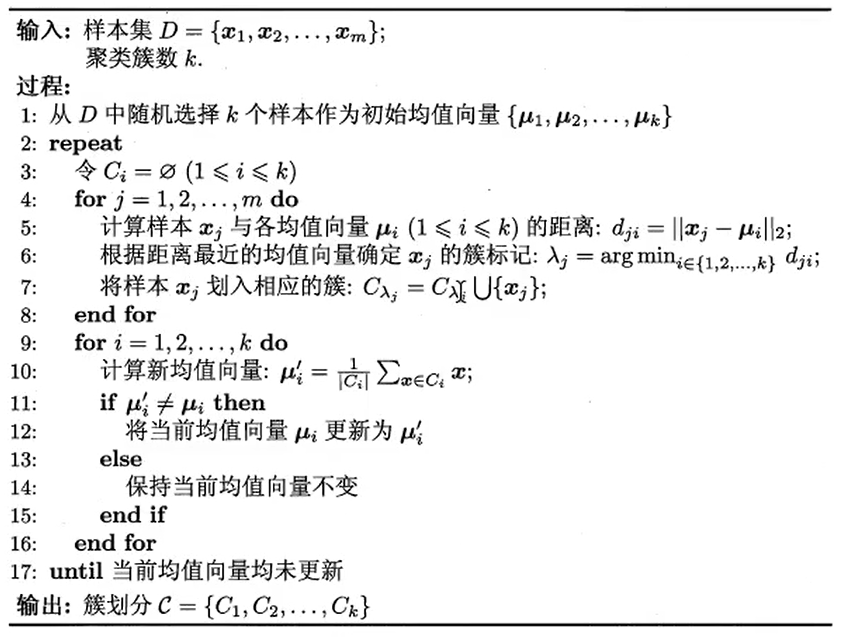

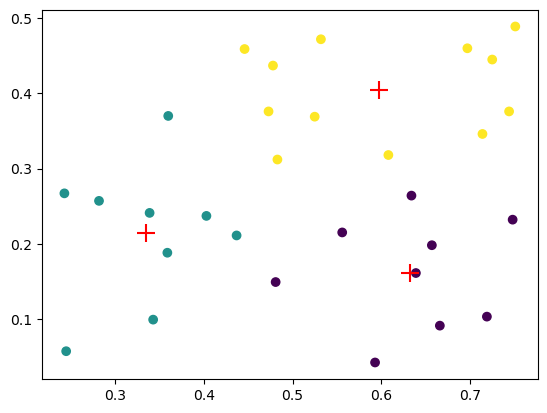

In [75]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self,k,max_iter = 10):
        """
        K-means聚类算法
        参数:
        k: 聚类簇数
        max_iter: 最大迭代次数
        """
        self.k = k
        self.max_iter = max_iter
        self.centroids  = None # 聚类中心
        self.labels = None # 聚类标签

    def calculate_distance(self,x,μ):
        """计算样本点与聚类中心之间的欧氏距离"""
        return np.sqrt(np.sum((x - μ)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的聚类中心索引"""
        return np.argmin(distances)
    
    def fit(self,data):
        """训练"""
        self.labels = np.zeros(len(data))
        # 随机选择K个样本点作为初始聚类中心
        # rand_index = np.random.choice(len(data),self.k,replace = False)
        rand_index = [5,11,23] # 与书上保持一样
        self.centroids = data[rand_index]
        # 迭代寻找最优解
        for i in range(self.max_iter):
            # E-step
            for j in range(len(data)):
                distances = []
                for k in range(self.k):
                    d = self.calculate_distance(data[j],self.centroids[k])
                    distances.append(d)
                # 找到最近的聚类中心
                closest_centroid = self.find_closest_centroid(distances)
                # 更新样本点的标签
                self.labels[j] = closest_centroid
            # M-step
            for j in range(self.k):
                # 更新聚类中心
                new_centroids = np.mean(data[self.labels == j],axis = 0)
                self.centroids[j] = new_centroids

if __name__ == '__main__':
    # 加载数据
    data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化KMeans
    kmeans = KMeans(k = 3,max_iter = 4)
    # 训练
    kmeans.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c = kmeans.labels)
    plt.scatter(kmeans.centroids[:,0],kmeans.centroids[:,1],marker = '+',s = 150,c = 'r')
    plt.show()

    




`学习向量量化(LVQ)`   
LVQ试图找到一组**原型向量**来刻画聚类结构，且要求数据样本带有**标签**。    
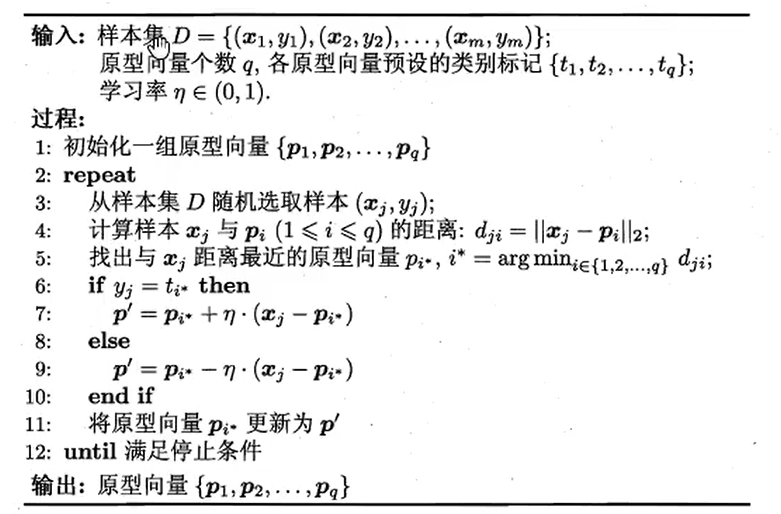    

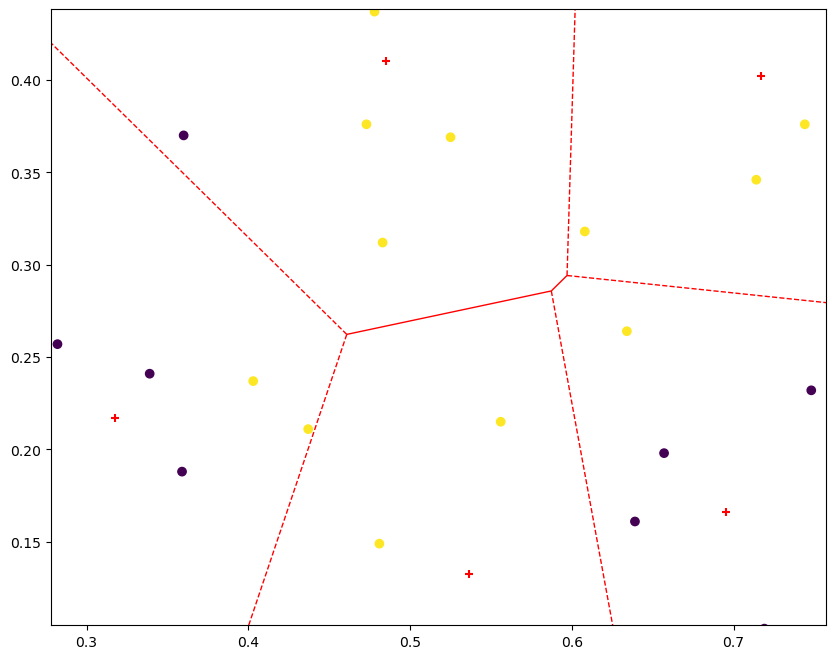

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d


class LVQ:
    def __init__(self,prototypes_pre_class,learning_rate=0.1,max_iter=100):
        """
        LVQ算法
        参数:
        prototypes_pre_class: 每个类别的原型向量个数(一个字典)
        learning_rate: 学习率
        max_iter: 最大迭代次数
        """
        self.prototypes_pre_class = prototypes_pre_class
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.p = None # 原型向量
        self.p_label = None # 原型向量标签

    def calculate_distance(self,x,p):
        """计算样本点与原型向量之间的欧氏距离"""
        return np.sqrt(np.sum((x - p)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的原型向量索引"""
        return np.argmin(distances)
    
    def fit(self,X,y):
        """训练"""
        # 初始化原型向量
        labels = np.unique(y)
        self.p = np.empty((0, X.shape[1]))
        self.p_label = np.array([])
        for label in labels:
            samples = X[y == label]
            idx = np.random.choice(len(samples),self.prototypes_pre_class[label],replace=False) 
            self.p = np.vstack((self.p, samples[idx])) # 纵向拼接
            self.p_label = np.hstack((self.p_label, label*np.ones(self.prototypes_pre_class[label]))) # 横向拼接
        # 迭代训练
        for i in range(self.max_iter):
            # 随机选取样本点
            idx = np.random.choice(len(X),1,replace=False)
            sample = X[idx[0]]
            label = y[idx]
            # 计算样本点与原型向量之间的距离
            distances = np.array([self.calculate_distance(sample,p) for p in self.p])
            # 找到最近的原型向量
            clostest_p_index = self.find_closest_centroid(distances)
            # 更新原型向量
            self.p[clostest_p_index] += self.learning_rate*(sample - self.p[clostest_p_index])
    
    
if __name__ == '__main__':
     # 加载数据
    data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 第9-21个样本标签为0，其他为1
    y = np.ones(len(data))
    y[8:21] = 0
    # 每个类的原型向量个数
    prototypes_pre_class = {0:2,1:3}
    # 实例化LVQ
    lvq = LVQ(prototypes_pre_class=prototypes_pre_class,learning_rate=0.1,max_iter=400)
    # 训练
    lvq.fit(data,y)
    # 可视化
    plt.figure(figsize=(10,8))
    plt.scatter(data[:,0],data[:,1],c=y)
    plt.scatter(lvq.p[:,0],lvq.p[:,1],c='r',marker='+')
    # 计算Voronoi图
    vor = Voronoi(lvq.p)
    voronoi_plot_2d(vor,ax=plt.gca(),show_points=False,show_vertices=False,line_colors='r')
    plt.show()
   
    

`高斯混合聚类`    
高斯混合聚类是采用**概率模型(高斯分布)**对原型进行刻画，簇划分由原型对应**后验概率**确定。   
假设样本的产生由高斯混合模型产生，高斯混合模型的形式为：    
$$
p_{\mathcal{M}}(\boldsymbol{x}) = \sum_{i=1}^{k} \alpha_{i} \cdot p\left(\boldsymbol{x} \mid \boldsymbol{\mu}_{i}, \boldsymbol{\Sigma}_{i}\right)
$$  
其中，$\alpha_{i}$为第$i$个高斯分布的权重，$\boldsymbol{\mu}_{i}$和$\boldsymbol{\Sigma}_{i}$为第$i$个高斯分布的均值和协方差矩阵。   
我们引入隐变量$z_{j}$，其代表第$j$个样本的高斯混合成分，通过贝叶斯定理，可以得到：    
$$
\begin{aligned}
p_{\mathcal{M}}\left(z_{j}=i \mid \boldsymbol{x}_{j}\right) &=\frac{P\left(z_{j}=i\right) \cdot p_{\mathcal{M}}\left(\boldsymbol{x}_{j} \mid z_{j}=i\right)}{p_{\mathcal{M}}\left(\boldsymbol{x}_{j}\right)} \\
&=\frac{\alpha_{i} \cdot p\left(\boldsymbol{x}_{j} \mid \boldsymbol{\mu}_{i}, \boldsymbol{\Sigma}_{i}\right)}{\sum_{l=1}^{k} \alpha_{l} \cdot p\left(\boldsymbol{x}_{j} \mid \boldsymbol{\mu}_{l}, \boldsymbol{\Sigma}_{l}\right)} .
\end{aligned}
$$
上式给出了样本$x_{j}$由第$i$个高斯分布生成的后验概率。   
以下给出求解混合高斯模型参数的过程：     
对数似然函数为：    
$$
\begin{aligned}
LL(D) &= \ln\left(\prod_{j=1}^{m} p_{\mathcal{M}}\left(\boldsymbol{x}_{j}\right)\right) \\
&= \sum_{j=1}^{m} \ln\left(\sum_{i=1}^{k} \alpha_{i} \cdot p\left(\boldsymbol{x}_{j} \mid \boldsymbol{\mu}_{i}, \boldsymbol{\Sigma}_{i}\right)\right)
\end{aligned}
$$
分别对上式的$\boldsymbol{\mu}_{i}$和$\boldsymbol{\Sigma}_{i}$求偏导，并令其为0，结合$p_{\mathcal{M}}\left(z_{j}=i \mid \boldsymbol{x}_{j}\right)$得：   
$$
\boldsymbol{\mu}_{i} = \frac{\sum_{j=1}^{m} \gamma_{ji} \boldsymbol{x}_{j}}{\sum_{j=1}^{m} \gamma_{ji}}
$$
$$
\boldsymbol{\Sigma}_{i} = \frac{\sum_{j=1}^{m} \gamma_{ji} \left(\boldsymbol{x}_{j} - \boldsymbol{\mu}_{i}\right) \left(\boldsymbol{x}_{j} - \boldsymbol{\mu}_{i}\right)^{\mathrm{T}}}{\sum_{j=1}^{m} \gamma_{ji}} .
$$
对于混合系数$\alpha_{i}$，结合拉格朗日乘子法，解得：    
$$
\alpha_{i} = \frac{1}{m} \sum_{j=1}^{m} \gamma_{ji}
$$
综上：  
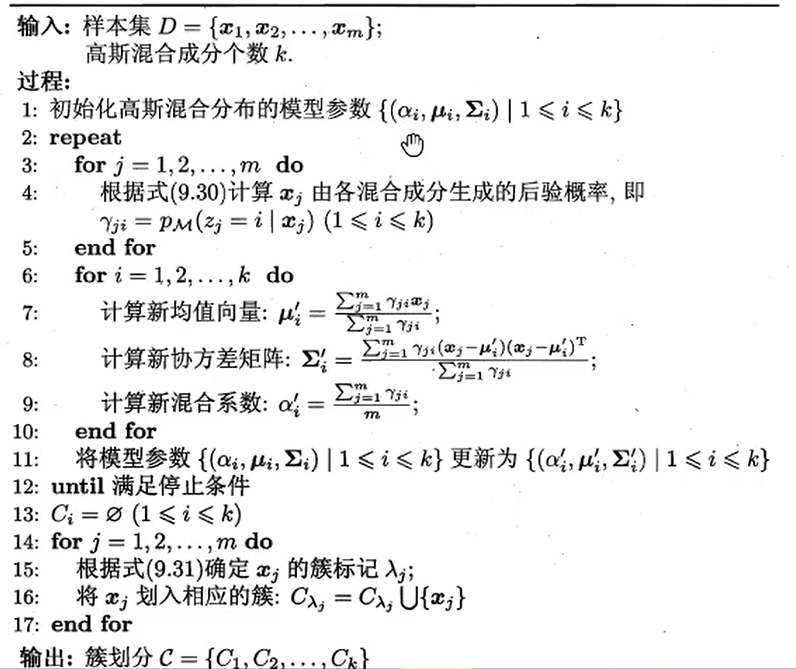

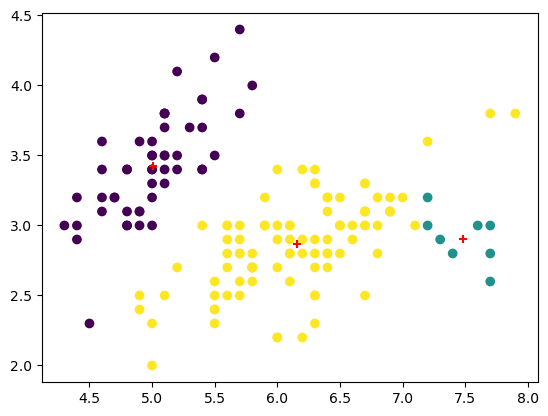

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

class GMM:
    """
    高斯混合聚类
    参数：
    k：聚类数
    max_iter：最大迭代次数
    """
    def __init__(self, k, max_iter=100):
        self.k = k
        self.max_iter = max_iter
        self.miu = None # 均值
        self.sigma = None # 方差
        self.alpha = None # 混合系数
        self.labels = None # 聚类结果

    def Gaussian(self,x,miu,sigma):
        """多元高斯分布"""
        n = len(miu)
        sigma = sigma + 1e-6*np.eye(n) # 引入正则化项，防止协方差矩阵奇异
        return 1.0/((2*np.pi)**(n/2)*np.linalg.det(sigma)**0.5)*np.exp(-0.5*np.dot(np.dot((x-miu).T,np.linalg.inv(sigma)),x-miu))
    
    def fit(self,X):
        """训练"""
        m,n = X.shape
        # 初始化高斯混合分布的模型参数
        # miu为k个n维向量
        idx = np.random.choice(m,self.k,replace=False)
        self.miu = X[idx]
        # sigma为k个n×n对称正定矩阵
        self.sigma =  np.random.rand(self.k,n,n)
        self.sigma = np.array([np.dot(sigma,sigma.T) for sigma in self.sigma])
        # 初始化alpha为均匀分布
        self.alpha = np.ones(self.k)/self.k
        # self.miu = X[[5,21,26]]
        # self.sigma = np.array([[[0.1,0],[0,0.1]]]*3)
        # self.alpha = np.array([1/3,1/3,1/3])

        # EM算法
        for i in range(self.max_iter):
            # E步
            # 计算每个样本属于每个高斯分布的概率
            p = np.zeros((m,self.k))
            for j in range(m):
                for k in range(self.k):
                    p[j,k] = self.alpha[k]*self.Gaussian(X[j],self.miu[k],self.sigma[k])
            p /= np.sum(p,axis=1,keepdims=True) # 归一化

            # M步
            # 更新高斯分布的模型参数
            for k in range(self.k):
                Nk = np.sum(p[:,k])
                self.miu[k] = np.sum(p[:,k].reshape(-1,1)*X,axis=0)/Nk
                self.sigma[k] = np.dot((X-self.miu[k]).T,p[:,k].reshape(-1,1)*(X-self.miu[k]))/Nk
                self.alpha[k] = Nk/m

        # 划分簇
        self.labels = np.argmax(p,axis=1)
       
        
if __name__ == '__main__':
    # 加载数据
    data = load_iris().data
    # data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化
    gmm = GMM(k=3,max_iter=200)
    # 训练
    gmm.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c=gmm.labels)
    plt.scatter(gmm.miu[:,0],gmm.miu[:,1],marker='+',c='r')
    plt.show()

### 9.4 密度聚类
密度聚类假设聚类结构能通过样本分布的**紧密程度**确定，并基于可连接性不断**扩展**聚类簇。    
定义几个概念：    
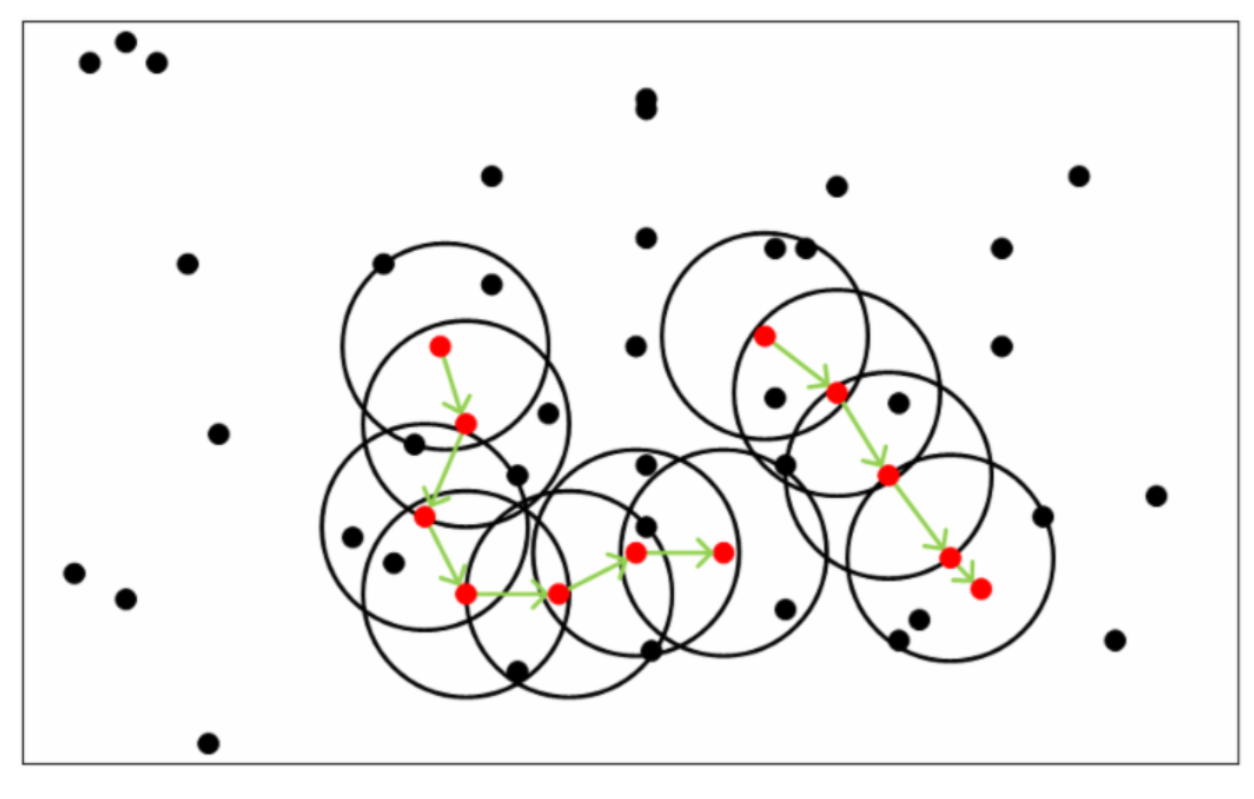     
其中红点表示核心对象，其满足：$\left|N_{\epsilon}\left(\boldsymbol{x}_{j}\right)\right| \geqslant \operatorname{MinPts}$，黑色圆圈的半径为$\epsilon$，表示核心对象的邻域。位于每一个核心对象圆圈内（eps-邻域）的点都可以由对应的核心对象**密度直达**，即绿色箭头所示。特别地，当邻域内也存在核心对象时，通过密度直达延伸，直到没有更多的核心对象为止，我们称终点由起点的核心对象**密度可达**，如图绿色箭头的起点和终点。而由一个核心对象向多个方向延伸，不同的终点**密度相连**，不难发现，**同一个簇里的对象之间是密度相连的**。   

`DBSCAN算法`   
DBSCAN算法将簇定义为：由密度可达关系导出的最大的密度相连的样本集合。其核心思路主要为以下两个步骤：
1. 任选一个核心对象作为种子
2. 由此出发并不断扩散以确定相应的聚类簇   
  
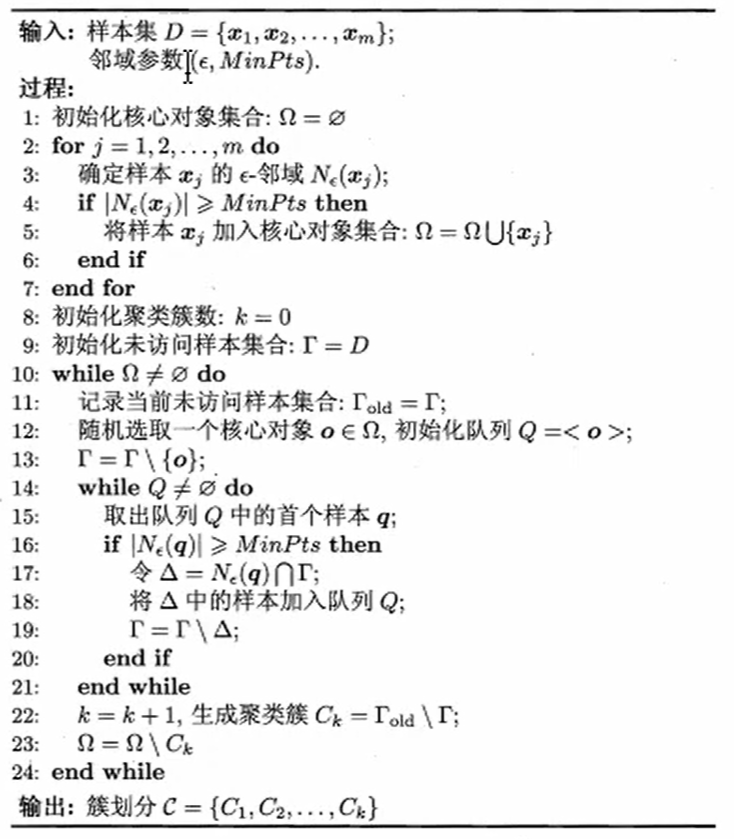    

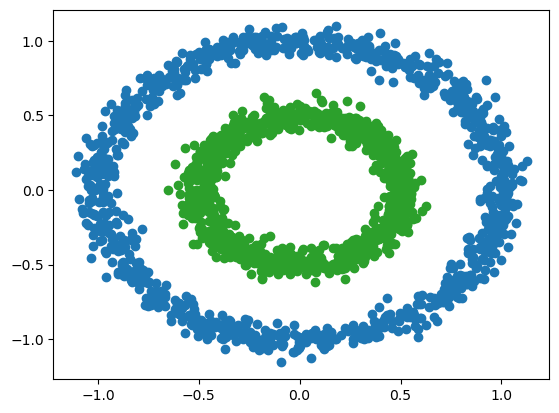

In [35]:
import numpy as np
import queue
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

class DBSCAN:
    def __init__(self,epsilon,MinPts):
        """
        DBSCAN算法
        参数：
        epsilon：邻域半径
        MinPts：核心对象最少需要的邻居数
        """
        self.epsilon = epsilon
        self.MinPts = MinPts
        self.core_objects = [] # 核心对象
        self.c = {} # 簇划分结果

    def calculate_distance(self,x1,x2):
        """计算两个点之间的距离"""
        return np.sqrt(np.sum((x1-x2)**2))

    def fit(self,X):
        """训练"""
        # 寻找核心对象
        for i in range(len(X)):
            x_neighbors = []
            for j in range(len(X)):
                if self.calculate_distance(X[i],X[j]) < self.epsilon:
                    x_neighbors.append(j)
            if len(x_neighbors) >= self.MinPts:
                self.core_objects.append(i)
        # 划分簇
        # 初始化聚类簇数
        k = 0 
        # 初始化未访问样本集合
        gamma = np.arange(len(X))
        while len(self.core_objects) > 0:
            # 记录当前未访问的样本集合
            gamma_old = gamma
            # 随机选择一个核心对象
            o = np.random.choice(self.core_objects)
            # 初始化队列
            Q = queue.Queue()
            Q.put(o)
            # 标记该核心对象已访问
            gamma = np.setdiff1d(gamma, o)
            while not Q.empty():
                # 取出队首元素
                q = Q.get()
                q_neighbors = []    
                # 判断该元素是否为核心对象
                for i in range(len(X)):
                    if self.calculate_distance(X[q],X[i]) < self.epsilon:
                        q_neighbors.append(i)
                # 该元素为核心对象，将其加入簇
                if len(q_neighbors) >= self.MinPts:
                    # q的邻居中未被访问的样本加入队列
                    for neighbor in q_neighbors:
                        if neighbor in gamma:
                            Q.put(neighbor)
                            # 标记delta为已访问
                            gamma = np.setdiff1d(gamma, neighbor)
            # 生成簇
            self.c[k] = np.setdiff1d(gamma_old, gamma)
            # 标记该簇的核心对象
            k += 1
            # 移去该簇的核心对象
            self.core_objects = np.setdiff1d(self.core_objects,self.c[k-1])
        # 噪声点
        self.c[-1] = np.setdiff1d(np.arange(len(X)), np.concatenate(list(self.c.values())))

                

if __name__ == '__main__':
    # 加载数据
    X, y = make_circles(n_samples=2000, noise=0.05, factor=0.5)
    # 实例化DBSCAN
    dbscan = DBSCAN(epsilon=0.2, MinPts=50)
    # 训练
    dbscan.fit(X)
    # 可视化
    for i in dbscan.c:
        if i != -1:
         # 绘制簇
            plt.scatter(X[dbscan.c[i],0],X[dbscan.c[i],1])
         # 绘制噪声
        plt.scatter(X[dbscan.c[-1],0],X[dbscan.c[-1],1],marker='*')
    plt.show()

 

### 9.5 层次聚类
层次聚类试图在**不同的层次**对数据集进行划分(一层一层分)，从而形成树状的结构，其包括两种策略:
1. 自底向上： 从每个样本开始，逐层合并
2. 自顶向下： 对所有样本进行划分，一分二，二分四...

`AGNES算法`
AGNES算法是采用自底向上策略进行层次聚类。其基本思想是：
1. 将数据集中的每一个样本看作是一个簇
2. 寻找距离最近的两个簇，将它们合并为一个新的簇
3. 重复步骤2，直到达到预期的聚类数目

常见的衡量簇间距离的式子有：     
最小距离$d_{\min}\left(C_{i}, C_{j}\right) = \min_{\boldsymbol{x} \in C_{i}, \boldsymbol{z} \in C_{j}} \operatorname{dist}(\boldsymbol{x}, \boldsymbol{z})$    
最大距离$d_{\max}\left(C_{i}, C_{j}\right) = \max_{\boldsymbol{x} \in C_{i}, \boldsymbol{z} \in C_{j}} \operatorname{dist}(\boldsymbol{x}, \boldsymbol{z})$     
平均距离$d_{\text{avg}}\left(C_{i}, C_{j}\right) = \frac{1}{\left|C_{i}\right|\left|C_{j}\right|} \sum_{\boldsymbol{x} \in C_{i}} \sum_{\boldsymbol{z} \in C_{j}} \operatorname{dist}(\boldsymbol{x}, \boldsymbol{z})$

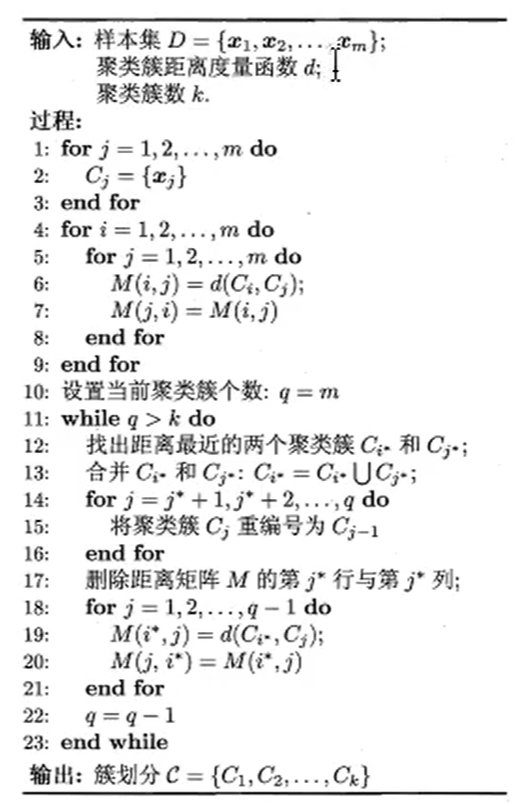    

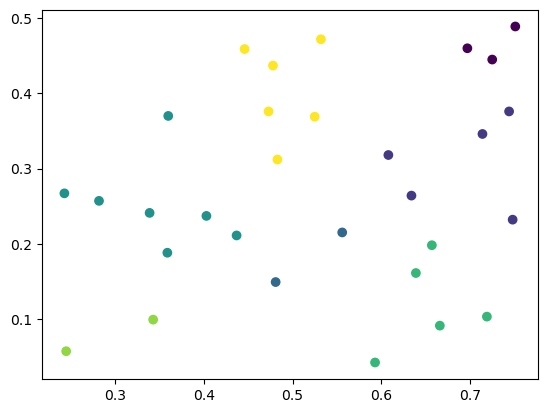

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class AGNES:
    def __init__(self,k,d):
        """
        AGNES算法
        参数：
        k:簇的个数
        d:聚类簇距离的度量函数('single', 'complete', 'average')
        """
        self.k = k
        self.d = d
        self.M = None # 距离矩阵，用于保存各个样本之间的距离
        self.labels = None # 聚类标签


    def calculate_distance(self,C1,C2):
        """计算两个簇之间的距离"""
        # 单链接 公式(9.41)
        if self.d =='single':
            min_dist = np.inf
            for i in C1:
                for j in C2:
                    if self.M[i,j] < min_dist:
                        min_dist = self.M[i,j]
            return min_dist
        # 全链接 公式(9.42)
        elif self.d == 'complete':
            max_dist = -np.inf
            for i in C1:
                for j in C2:
                    if self.M[i,j] > max_dist:
                        max_dist = self.M[i,j]
            return max_dist
        # 平均链接 公式(9.43)
        elif self.d == 'average':
            dist_sum = 0
            for i in C1:
                for j in C2:
                    dist_sum += self.M[i,j]
            return dist_sum/len(C1)/len(C2)
        else:
            print('距离度量函数错误！')
            return None

    def fit(self,X):
        """训练"""
        m = X.shape[0] # 样本个数
        self.M = np.zeros((m,m)) # 距离矩阵初始化
        # 计算距离矩阵
        for i in range(m):
            for j in range(i+1,m):
                self.M[i,j] = self.M[j,i] = np.linalg.norm(X[i]-X[j])
        # 初始化用于更新的距离矩阵
        distance_matrix = self.M.copy() 
        # 初始化簇,每一个样本都是一个簇
        c = [[i] for i in range(m)]
        # 初始化当前簇的个数
        q = m
        # 聚类
        while q > self.k:
            # 选择最小距离的两个簇
            min_dist = np.inf
            for i in range(q):
                for j in range(i+1,q):
                    if distance_matrix[i,j] < min_dist:
                        min_dist = distance_matrix[i,j]
                        i_min,j_min = i,j
            # 合并两个簇
            c[i_min].extend(c[j_min])
            del c[j_min]

            # 更新距离矩阵
            distance_matrix = np.delete(distance_matrix,j_min,axis=0)
            distance_matrix = np.delete(distance_matrix,j_min,axis=1)
            for j in range(q-1):
                if j != i_min:
                    distance = self.calculate_distance(c[i_min],c[j])
                    distance_matrix[i_min,j] = distance
                    distance_matrix[j,i_min] = distance
                else:
                    distance_matrix[i_min,j] = 0
            
            q -= 1
    
        # 生成标签
        self.labels = np.zeros(m,dtype=int)
        for lable,samples in enumerate(c):
            for i in samples:
                self.labels[i] = lable
            
if __name__ == '__main__':
    # 加载数据
    data = np.loadtxt('./Data/4.0.csv',dtype = float,delimiter = ',')
    # 实例化AGNES
    agnes = AGNES(k=7,d='complete')
    # 训练
    agnes.fit(data)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c=agnes.labels)
    plt.show()